### 소윤님 코드 공부하기

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import ast

# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings

warnings.filterwarnings("ignore")

# 폰트 설정(없으면 영문으로 나옴)
try:
    font_path = [f for f in fm.findSystemFonts() if "NanumGothic" in f or "Malgun" in f or "AppleGothic" in f]
    if font_path:
        plt.rcParams["font.family"] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams["font.family"] = "DejaVu Sans"
except:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

In [2]:
full = pd.read_csv("../pjh_EDA/preprocessed_final.csv")

In [3]:
# 날짜 변환 (혹시 안 했으면)
full["became_member_on"] = pd.to_datetime(full["became_member_on"], errors="coerce")

# 가입 연도
full["join_year"] = full["became_member_on"].dt.year

# 가입 월 (숫자)
full["join_month"] = full["became_member_on"].dt.month

# 가입 연-월 (문자형)
full["join_year_month"] = full["became_member_on"].dt.strftime("%Y-%m")

# cohort
full["join_cohort"] = full["became_member_on"].dt.to_period("M")

In [4]:
print("[ 가입 연도 분포 ]")
customer_df = full.drop_duplicates("customer_id")
display(customer_df["join_year"].value_counts().sort_index())

print("[ 가입 월 분포 ]")
display(customer_df["join_month"].value_counts().sort_index())

print("[ Cohort 분포 ]")
display(customer_df["join_cohort"].value_counts().sort_index())

[ 가입 연도 분포 ]


join_year
2013     286
2014     691
2015    1830
2016    3526
2017    6469
2018    4198
Name: count, dtype: int64

[ 가입 월 분포 ]


join_month
1     1525
2     1202
3     1329
4     1315
5     1307
6     1265
7     1359
8     1610
9     1515
10    1568
11    1449
12    1556
Name: count, dtype: int64

[ Cohort 분포 ]


join_cohort
2013-07      5
2013-08     68
2013-09     57
2013-10     56
2013-11     48
          ... 
2018-03    618
2018-04    585
2018-05    601
2018-06    562
2018-07    506
Freq: M, Name: count, Length: 61, dtype: int64

- events_df : 누락 제거된 df , 성별, 수입 누락(2175) 뺀 거 
- event_time_col : 시간 
- recv_keys :  received 한 정보 모음
- _row_id : 이벤트 행을 식별자 (인덱스 개념) 
- valid : 시간 (t_received<=event_time_col<=t_expire) 필터링
- match_cnt : 각 오퍼 인스턴스가 몇 번 received 되었는가?
- match_count : 동일한 viewed 이벤트가 몇 번 수신 구간에 들어왔는지 카운트 
- ambiguous_match : 첫 오퍼를 받은 이후 아직 duration내에 또다른(같은 offer_id) 오퍼를 또 받았으니, 가장 최근 instance로 결정


## 최종 코드 흐름 정리
received / viewed / completed 분리

instance_id 부여 + t_expire 계산

interval_join -> view_map, comp_map

view_summary, comp_summary 집계

funnel_instance 생성 (received + view_summary + comp_summary)

gap 파생변수 계산

퍼널 플래그 (is_viewed, is_completed)

completed_without_view + nan 처리

is_aware + is_aware_reliable  ← 추가 위치

퍼널 요약 출력

In [5]:
# 1. 이벤트 분리 + instance_id + t_expire
received = (
    full.loc[full["event"] == "offer received", ["customer_id", "offer_id", "time", "offer_type"]]
    .rename(columns={"time": "t_received"})
    .sort_values(["customer_id", "offer_id", "t_received"])
    .reset_index(drop=True)
)
viewed = (
    full.loc[full["event"] == "offer viewed", ["customer_id", "offer_id", "time", "offer_type"]]
    .rename(columns={"time": "t_viewed"})
    .sort_values(["customer_id", "offer_id", "t_viewed"])
    .reset_index(drop=True)
)
completed = (
    full.loc[full["event"] == "offer completed", ["customer_id", "offer_id", "time", "offer_type"]]
    .rename(columns={"time": "t_completed"})
    .sort_values(["customer_id", "offer_id", "t_completed"])
    .reset_index(drop=True)
)

received["instance_id"] = received.groupby(["customer_id", "offer_id"]).cumcount() + 1

portfolio_dur = full[["offer_id", "duration"]].dropna(subset=["offer_id"]).drop_duplicates("offer_id")

received = received.merge(portfolio_dur, on="offer_id", how="left")

# [경계조건] t_expire = t_received + duration * 24
# transcript.time 단위: hour / portfolio.duration 단위: day -> *24
# 양 끝 포함 (closed interval), strict(<) 미사용
received["t_expire"] = received["t_received"] + received["duration"] * 24

recv_keys = received[["customer_id", "offer_id", "t_received", "instance_id", "t_expire"]]


# 2. interval_join
# events_df: offer viewed 또는 offer completed 이벤트만 필터링한 테이블
# _row_id: merge 전 원본 행 고유번호 (1행 → N행으로 늘어날 때 추적용)
def interval_join(events_df, event_time_col):
    # [경계조건] t_received <= t_event <= t_expire (양 끝 포함)
    # [ambiguous match 처리] 복수 구간에 걸리면 가장 최근 수신 instance 선택
    events_df = events_df.copy()
    events_df["_row_id"] = range(len(events_df))

    merged = events_df.merge(recv_keys, on=["customer_id", "offer_id"], how="left")
    valid = merged[
        (merged["t_received"] <= merged[event_time_col]) & (merged[event_time_col] <= merged["t_expire"])
    ].copy()

    match_cnt = valid.groupby("_row_id")["instance_id"].count().reset_index(name="match_count")

    valid = valid.merge(match_cnt, on="_row_id")

    valid["ambiguous_match"] = (valid["match_count"] > 1).astype(int)
    valid = (
        valid.sort_values("t_received", ascending=False)
        .drop_duplicates(subset="_row_id", keep="first")
        .drop(columns="_row_id")
    )
    return valid


view_map = interval_join(viewed, "t_viewed")
comp_map = interval_join(completed, "t_completed")

n_no_match_v = len(viewed) - len(view_map)
n_no_match_c = len(completed) - len(comp_map)

n_ambig_v = view_map["ambiguous_match"].sum()
n_ambig_c = comp_map["ambiguous_match"].sum()

print(f"열람: 유효 구간 밖 {n_no_match_v:,}건 / ambiguous {n_ambig_v:,}건")
print(f"완료: 유효 구간 밖 {n_no_match_c:,}건 / ambiguous {n_ambig_c:,}건")


# 3. 인스턴스별 요약
view_summary = view_map.groupby(["customer_id", "offer_id", "instance_id"], as_index=False).agg(
    first_viewed=("t_viewed", "min"),
    last_viewed=("t_viewed", "max"),
    view_count=("t_viewed", "count"),
    view_ambiguous=("ambiguous_match", "max"),
)

comp_summary = comp_map.groupby(["customer_id", "offer_id", "instance_id"], as_index=False).agg(
    first_completed=("t_completed", "min"),
    last_completed=("t_completed", "max"),
    complete_count=("t_completed", "count"),
    comp_ambiguous=("ambiguous_match", "max"),
)


# 4. funnel_instance 생성
funnel_instance = received.merge(view_summary, on=["customer_id", "offer_id", "instance_id"], how="left").merge(
    comp_summary, on=["customer_id", "offer_id", "instance_id"], how="left"
)


# 5. gap 파생변수 (first_ 컬럼명 기준)
funnel_instance["gap_to_first_view"] = funnel_instance["first_viewed"] - funnel_instance["t_received"]
funnel_instance["gap_to_first_complete"] = funnel_instance["first_completed"] - funnel_instance["t_received"]
funnel_instance["gap_first_view_to_first_complete"] = (
    funnel_instance["first_completed"] - funnel_instance["first_viewed"]
)
funnel_instance["gap_to_first_view_day"] = funnel_instance["gap_to_first_view"] / 24
funnel_instance["gap_to_first_complete_day"] = funnel_instance["gap_to_first_complete"] / 24
funnel_instance["gap_first_view_to_first_complete_day"] = funnel_instance["gap_first_view_to_first_complete"] / 24


# 6. 컬럼명 통일 (first_ → t_, gap_to_first_ → gap_to_)
funnel_instance = funnel_instance.rename(
    columns={
        "first_viewed": "t_viewed",
        "first_completed": "t_completed",
        "gap_to_first_view": "gap_to_view",
        "gap_to_first_complete": "gap_to_complete",
        "gap_first_view_to_first_complete": "gap_view_to_complete",
        "gap_to_first_view_day": "gap_to_view_day",
        "gap_to_first_complete_day": "gap_to_complete_day",
        "gap_first_view_to_first_complete_day": "gap_view_to_complete_day",
    }
)


# 7. 퍼널 플래그 (rename 이후 컬럼명 기준)
funnel_instance["is_viewed"] = funnel_instance["t_viewed"].notna()
funnel_instance["is_completed"] = funnel_instance["t_completed"].notna()

# completed_without_view: 조회없이 완료 or 완료 후 조회(gap<0)
funnel_instance["was_viewed"] = funnel_instance["t_viewed"].notna().astype(int)
funnel_instance["was_completed"] = funnel_instance["t_completed"].notna().astype(int)

funnel_instance["completed_without_view"] = (
    ((funnel_instance["was_completed"] == 1) & (funnel_instance["was_viewed"] == 0))
    | (funnel_instance["gap_view_to_complete_day"] < 0)
).astype(int)

# 음수 gap은 의미 없으므로 nan 처리
funnel_instance.loc[funnel_instance["completed_without_view"] == 1, "gap_view_to_complete_day"] = np.nan

# valid_view_sequence
funnel_instance["valid_view_sequence"] = (
    funnel_instance["t_viewed"].notna()
    & funnel_instance["t_completed"].notna()
    & (funnel_instance["t_viewed"] <= funnel_instance["t_completed"])
).astype(int)


# 8. is_aware 정의
# is_aware = is_viewed & is_completed & completed_without_view==0
# → valid_view_sequence와 수학적으로 동치
# → completed_without_view가 이미 (미조회 | gap<0) 케이스를 모두 잡기 때문
funnel_instance["is_aware"] = (
    funnel_instance["is_viewed"].astype(bool)
    & funnel_instance["is_completed"].astype(bool)
    & (funnel_instance["completed_without_view"] == 0)
).astype(int)

# is_aware_reliable: ambiguous 제외
funnel_instance["is_aware_reliable"] = (
    (funnel_instance["is_aware"] == 1)
    & (funnel_instance["comp_ambiguous"] == 0)
    & (funnel_instance["view_ambiguous"] == 0)
).astype(int)

# 9. CSV 저장 + 완료 인스턴스 서브셋
funnel_instance.to_csv("../pjh_EDA/funnel_instance.csv", index=False)
completed_funnel_instance = funnel_instance[funnel_instance["is_completed"]].copy()


# 10. 요약 출력
print(f"\n전체 오퍼 received 인스턴스 수: {len(funnel_instance):,}건")

print("\n[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]")
v = funnel_instance["gap_to_view"].dropna()
print(f"  평균   : {v.mean():.1f}시간 ({v.mean()/24:.1f}일)")
print(f"  중앙값 : {v.median():.1f}시간 ({v.median()/24:.1f}일)")
print(f"  6시간 내 열람 : {(v <= 6).mean()*100:.1f}%")
print(f"  24시간 내 열람: {(v <= 24).mean()*100:.1f}%")
print(f"  48시간 내 열람: {(v <= 48).mean()*100:.1f}%")

print("\n[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]")
c = funnel_instance["gap_to_complete"].dropna()
print(f"  평균   : {c.mean():.1f}시간 ({c.mean()/24:.1f}일)")
print(f"  중앙값 : {c.median():.1f}시간 ({c.median()/24:.1f}일)")
print(f"  1일 내 완료: {(c <= 24).mean()*100:.1f}%")
print(f"  3일 내 완료: {(c <= 72).mean()*100:.1f}%")
print(f"  7일 내 완료: {(c <= 168).mean()*100:.1f}%")

print("\n[ 퍼널 요약 ]")
print(f"  Viewed rate          : {funnel_instance['is_viewed'].mean()*100:.1f}%")
print(f"  Completed rate       : {funnel_instance['is_completed'].mean()*100:.1f}%")
print(f"  완료했지만 미열람     : {funnel_instance['completed_without_view'].mean()*100:.1f}%")
print(f"  is_aware             : {funnel_instance['is_aware'].mean()*100:.1f}%")
print(f"  is_aware_reliable    : {funnel_instance['is_aware_reliable'].mean()*100:.1f}%")

열람: 유효 구간 밖 1,158건 / ambiguous 2,339건
완료: 유효 구간 밖 0건 / ambiguous 1,776건

전체 오퍼 received 인스턴스 수: 76,277건

[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]
  평균   : 24.4시간 (1.0일)
  중앙값 : 12.0시간 (0.5일)
  6시간 내 열람 : 38.5%
  24시간 내 열람: 67.3%
  48시간 내 열람: 85.2%

[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]
  평균   : 61.2시간 (2.5일)
  중앙값 : 48.0시간 (2.0일)
  1일 내 완료: 31.2%
  3일 내 완료: 66.8%
  7일 내 완료: 96.7%

[ 퍼널 요약 ]
  Viewed rate          : 74.2%
  Completed rate       : 43.4%
  완료했지만 미열람     : 12.9%
  is_aware             : 30.5%
  is_aware_reliable    : 28.9%


#### funnel_instance 기반 is_aware 정의
조건
1. 유효기간 내 완료 (is_completed == True)
2. 유효기간 내 조회 (is_viewed == True)
3. 조회가 완료보다 먼저 발생 (t_viewed <= t_completed)
4. 유효기간 내 이벤트 (within_duration == True)

valid_view_sequence가 이미 1~3을 통합한 컬럼
1. is_viewed == True
2. is_completed == True
3. t_viewed <= t_completed
    + funnel_instance 자체가 within_duration 보장

- is_aware = is_viewed & is_completed & completed_without_view==0
- -> valid_view_sequence
- completed_without_view가 이미 (미조회 | gap<0) 케이스를 모두 잡기 때문


In [6]:
first_viewed_instance = (
    funnel_instance[funnel_instance["is_viewed"]]
    .groupby(["customer_id", "offer_id"])["instance_id"]
    .min()
    .reset_index(name="first_viewed_instance")
)

In [7]:
first_viewed_instance

,customer_id,offer_id,first_viewed_instance
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,1
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,1
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,1
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,1
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,1
...,...,...,...
48208,fffad4f4828548d1b5583907f2e9906b,f19421c1d4aa40978ebb69ca19b0e20d,1
48209,ffff82501cea40309d5fdd7edcca4a07,0b1e1539f2cc45b7b9fa7c272da2e1d7,1
48210,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,1
48211,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,1


In [8]:
first_viewed_instance["first_viewed_instance"].value_counts()
# => 같은 이벤트 3,4번째 보는 사람들은 안보는 경향 보임

first_viewed_instance
1    47024
2     1146
3       42
4        1
Name: count, dtype: int64

In [9]:
(first_viewed_instance["first_viewed_instance"].value_counts(normalize=True) * 100).round(2)

first_viewed_instance
1    97.53
2     2.38
3     0.09
4     0.00
Name: proportion, dtype: float64

In [10]:
funnel_instance.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 't_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_view', 'gap_to_complete',
       'gap_view_to_complete', 'gap_to_view_day', 'gap_to_complete_day',
       'gap_view_to_complete_day', 'is_viewed', 'is_completed', 'was_viewed',
       'was_completed', 'completed_without_view', 'valid_view_sequence',
       'is_aware', 'is_aware_reliable'],
      dtype='str')

In [11]:
funnel_instance[
    ["customer_id", "offer_id", "t_received", "offer_type", "instance_id", "is_viewed", "is_completed"]
].head()

,customer_id,offer_id,t_received,offer_type,instance_id,is_viewed,is_completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,False,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,True,False
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,True,False
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,True,True
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,True,True


In [12]:
funnel_instance.groupby(["customer_id", "offer_id", "instance_id"])[["is_viewed", "is_completed"]].first().reset_index()

,customer_id,offer_id,instance_id,is_viewed,is_completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,1,False,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,1,True,False
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,1,True,False
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,1,True,True
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,1,True,True
...,...,...,...,...,...
76272,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,1,True,True
76273,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,2,True,True
76274,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,3,True,True
76275,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,True,True


In [13]:
funnel_instance.groupby("customer_id")["instance_id"].apply(list).reset_index().head()

,customer_id,instance_id
0,0009655768c64bdeb2e877511632db8f,"[1, 1, 1, 1, 1]"
1,00116118485d4dfda04fdbaba9a87b5c,"[1, 2]"
2,0011e0d4e6b944f998e987f904e8c1e5,"[1, 1, 1, 1, 1]"
3,0020c2b971eb4e9188eac86d93036a77,"[1, 1, 1, 1, 2]"
4,0020ccbbb6d84e358d3414a3ff76cffd,"[1, 1, 1, 1]"


In [14]:
funnel_instance[funnel_instance["is_viewed"]].groupby("customer_id")["instance_id"].apply(list).reset_index()

,customer_id,instance_id
0,0009655768c64bdeb2e877511632db8f,"[1, 1, 1, 1]"
1,00116118485d4dfda04fdbaba9a87b5c,"[1, 2]"
2,0011e0d4e6b944f998e987f904e8c1e5,"[1, 1, 1, 1, 1]"
3,0020c2b971eb4e9188eac86d93036a77,"[1, 1]"
4,0020ccbbb6d84e358d3414a3ff76cffd,"[1, 1, 1, 1]"
...,...,...
16788,fff3ba4757bd42088c044ca26d73817a,"[2, 1, 1]"
16789,fff7576017104bcc8677a8d63322b5e1,"[1, 1, 1, 2]"
16790,fff8957ea8b240a6b5e634b6ee8eafcf,"[1, 1]"
16791,fffad4f4828548d1b5583907f2e9906b,"[1, 1, 1, 2]"


- 0009...  [1, 1, 1, 1, 1]  → 5개 오퍼를 받았고 모두 첫 번째 수신 (같은 오퍼를 두 번 받은 경우 없음)
- 00116... [1, 2]           → 같은 오퍼를 2번 받음 (instance_id 1, 2)
- 0020c... [1, 1, 1, 1, 2]  → 4개는 첫 수신, 1개는 같은 오퍼를 두 번째로 받음

In [15]:
print("received 원건수:", len(received))
print("instance funnel 원건수:", len(funnel_instance))

received 원건수: 76277
instance funnel 원건수: 76277


In [16]:
print("Viewed rate:", funnel_instance["is_viewed"].mean())
print("Completed rate:", funnel_instance["is_completed"].mean())
print("Completed without view:", (funnel_instance["is_completed"] & ~funnel_instance["is_viewed"]).mean())
# 오퍼 노출은 잘 된다
# 전환에서 크게 떨어진다
# 사용자가 오퍼를 안 보고도
# 조건을 충족해서 reward를 받음

Viewed rate: 0.7415996958454055
Completed rate: 0.4339578116601335
Completed without view: 0.07510783066979561


In [17]:
print((funnel_instance["gap_to_view"] < 0).sum())
print((funnel_instance["gap_to_complete"] < 0).sum())
print((funnel_instance["gap_view_to_complete"] < 0).sum())
# completed < viewed
# 완료가 열람보다 먼저 발생 -> viewed 없이도 completion 가능

0
0
4105


In [18]:
# 중복확인
funnel_instance[["customer_id", "offer_id", "instance_id"]].duplicated().sum()

np.int64(0)

In [19]:
funnel_instance.groupby("offer_type")[["is_viewed", "is_completed"]].mean()

,is_viewed,is_completed
offer_type,,
bogo,0.827896,0.508246
discount,0.699669,0.576237
informational,0.652904,0.000000


In [20]:
funnel_instance.groupby("offer_type")["gap_to_complete"].median()

offer_type
bogo             42.0
discount         60.0
informational     NaN
Name: gap_to_complete, dtype: float64

In [21]:
portfolio = (
    full[["offer_id", "duration", "offer_type"]]
    .dropna(subset=["offer_id", "duration"])
    .drop_duplicates("offer_id")
    .rename(columns={"duration": "offer_duration", "offer_type": "offer_type_port"})
)
# 방어 코드
funnel_instance = funnel_instance.drop(
    columns=["offer_duration", "offer_type_port", "duration_hours", "within_duration"], errors="ignore"
)

funnel_instance = funnel_instance.merge(portfolio, on="offer_id", how="left")
funnel_instance["duration_hours"] = funnel_instance["offer_duration"] * 24
funnel_instance["within_duration"] = funnel_instance["gap_to_complete"].notna() & (
    funnel_instance["gap_to_complete"] <= funnel_instance["duration_hours"]
)

completed_funnel_instance = funnel_instance[funnel_instance["is_completed"]].copy()

print(f"전체 수신 인스턴스: {len(funnel_instance):,}건  /  완료: {len(completed_funnel_instance):,}건")

within_cnt = funnel_instance["within_duration"].sum()
print(f"유효기간 내 완료 (수신 대비): {within_cnt:,}건 ({within_cnt / len(funnel_instance) * 100:.1f}%)")
print(f"유효기간 내 완료 (완료 대비, 참고): {completed_funnel_instance['within_duration'].mean()*100:.1f}%")

print("\n[ duration별 ]")
dur_rate = completed_funnel_instance.groupby("offer_duration")["within_duration"].agg(["sum", "count", "mean"])
dur_rate.columns = ["유효기간 내 완료", "전체 완료", "완료율"]
dur_rate["완료율"] = dur_rate["완료율"].map(lambda x: f"{x*100:.1f}%")
print(dur_rate)

print("\n[ 오퍼 유형별 평균 반응 시간 ]")
for otype in ["bogo", "discount"]:
    df = completed_funnel_instance.loc[completed_funnel_instance["offer_type_port"] == otype, "gap_to_complete"]
    print(f"  {otype:<12} 평균 {df.mean()/24:.1f}일  중앙값 {df.median()/24:.1f}일")

전체 수신 인스턴스: 76,277건  /  완료: 33,101건
유효기간 내 완료 (수신 대비): 33,101건 (43.4%)
유효기간 내 완료 (완료 대비, 참고): 100.0%

[ duration별 ]
                유효기간 내 완료  전체 완료     완료율
offer_duration                          
5.0                  7563   7563  100.0%
7.0                 16995  16995  100.0%
10.0                 8543   8543  100.0%

[ 오퍼 유형별 평균 반응 시간 ]
  bogo         평균 2.1일  중앙값 1.8일
  discount     평균 3.0일  중앙값 2.5일


In [23]:
# received에 이미 duration, t_expire 포함
received_with_dur = received

tx = (
    full[full["event"] == "transaction"][
        [
            "customer_id",
            "time",
            "amount",
            "income_group",
            "age_group",
            "age_gender",
            "join_year",
            "join_month",
            "join_year_month",
            "join_cohort",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

recv = received_with_dur[["customer_id", "t_received", "t_expire"]].copy()
tx_recv = tx.merge(recv, on="customer_id", how="left")
tx_recv["is_active"] = (tx_recv["t_received"] <= tx_recv["time"]) & (tx_recv["t_expire"] >= tx_recv["time"])

active_flag = (
    tx_recv.groupby(["customer_id", "time"])["is_active"]
    .any()
    .reset_index()
    .rename(columns={"is_active": "has_active_offer"})
)

tx = tx.merge(active_flag, on=["customer_id", "time"], how="left")
tx["has_active_offer"] = tx["has_active_offer"].fillna(False)
# is_natural = 활성 오퍼 없는 시점의 거래 (동시성이며 인과 아님)
tx["is_natural"] = ~tx["has_active_offer"]

nact_tx = tx[tx["is_natural"]].copy()
act_tx = tx[~tx["is_natural"]].copy()

print(f"전체 transaction: {len(tx):,}건")
print(f"자연 거래 (오퍼 없음): {len(nact_tx):,}건 ({len(nact_tx)/len(tx)*100:.1f}%)")
print(f"오퍼 활성 중 거래:     {len(act_tx):,}건 ({len(act_tx)/len(tx)*100:.1f}%)")

print("\n[ 자연 거래 vs 오퍼 중 거래 평균 금액 ]")
print(f"  자연 거래 평균    : ${nact_tx['amount'].mean():.2f}")
print(f"  오퍼 중 거래 평균 : ${act_tx['amount'].mean():.2f}")
print(f"  차이 (오퍼-자연)  : ${act_tx['amount'].mean() - nact_tx['amount'].mean():.2f}")


def print_dist(df, col, title, order=None):
    print(f"\n[ {title} ]")
    if order is None:
        for v, c in df[col].value_counts(dropna=False).items():
            print(f"  {str(v):<15} {c:>6,}건 ({c/len(df)*100:.1f}%)")
    else:
        for v in order:
            c = (df[col] == v).sum()
            print(f"  {str(v):<15} {c:>6,}건 ({c/len(df)*100:.1f}%)")


inc_order = ["누락", "5만 미만", "5-7.5만", "7.5-10만", "10만 이상"]
age_order = ["누락", "20대 미만", "20대", "30대", "40대", "50대", "60대 이상"]

age_gender_order = ["미기입", "Others"]
for g in ["남성", "여성"]:
    for a in ["20세 미만", "20대", "30대", "40대", "50대", "60대", "60+"]:
        age_gender_order.append(f"{a} {g}")

print_dist(nact_tx, "income_group", "자연 거래 소득 구간 분포", inc_order)
print_dist(nact_tx, "age_group", "자연 거래 연령대 분포", age_order)

print("\n[ 세그먼트별 자연 거래 비율 ]")
for idx, val in tx.groupby("income_group")["is_natural"].mean().reindex(inc_order).items():
    print(f"  {idx:<15} {val*100:>5.1f}%")

print()
for idx, val in tx.groupby("age_group")["is_natural"].mean().reindex(age_order).items():
    print(f"  {idx:<15} {val*100:>5.1f}%")

print()
for idx, val in tx.groupby("join_year")["is_natural"].mean().sort_index().items():
    print(f"  {str(idx):<15} {val*100:>5.1f}%")

customer_nat_ratio = tx.groupby("customer_id")["is_natural"].mean().reset_index(name="natural_tx_ratio")
print("\n[ 고객 단위 자연 거래 비율 ]")
print(customer_nat_ratio["natural_tx_ratio"].describe())

전체 transaction: 138,953건
자연 거래 (오퍼 없음): 17,090건 (12.3%)
오퍼 활성 중 거래:     121,863건 (87.7%)

[ 자연 거래 vs 오퍼 중 거래 평균 금액 ]
  자연 거래 평균    : $12.76
  오퍼 중 거래 평균 : $12.78
  차이 (오퍼-자연)  : $0.02

[ 자연 거래 소득 구간 분포 ]
  누락               1,994건 (11.7%)
  5만 미만            4,446건 (26.0%)
  5-7.5만           6,923건 (40.5%)
  7.5-10만          2,910건 (17.0%)
  10만 이상             817건 (4.8%)

[ 자연 거래 연령대 분포 ]
  누락               1,994건 (11.7%)
  20대 미만             246건 (1.4%)
  20대              1,565건 (9.2%)
  30대              1,746건 (10.2%)
  40대              2,418건 (14.1%)
  50대              3,451건 (20.2%)
  60대 이상           5,670건 (33.2%)

[ 세그먼트별 자연 거래 비율 ]
  누락               13.3%
  5만 미만            11.7%
  5-7.5만           12.2%
  7.5-10만          13.0%
  10만 이상           12.3%

  누락               13.3%
  20대 미만           11.9%
  20대              11.1%
  30대              11.4%
  40대              12.6%
  50대              12.5%
  60대 이상           12.4%

  2013             10.2%
  2014             10.8%
 

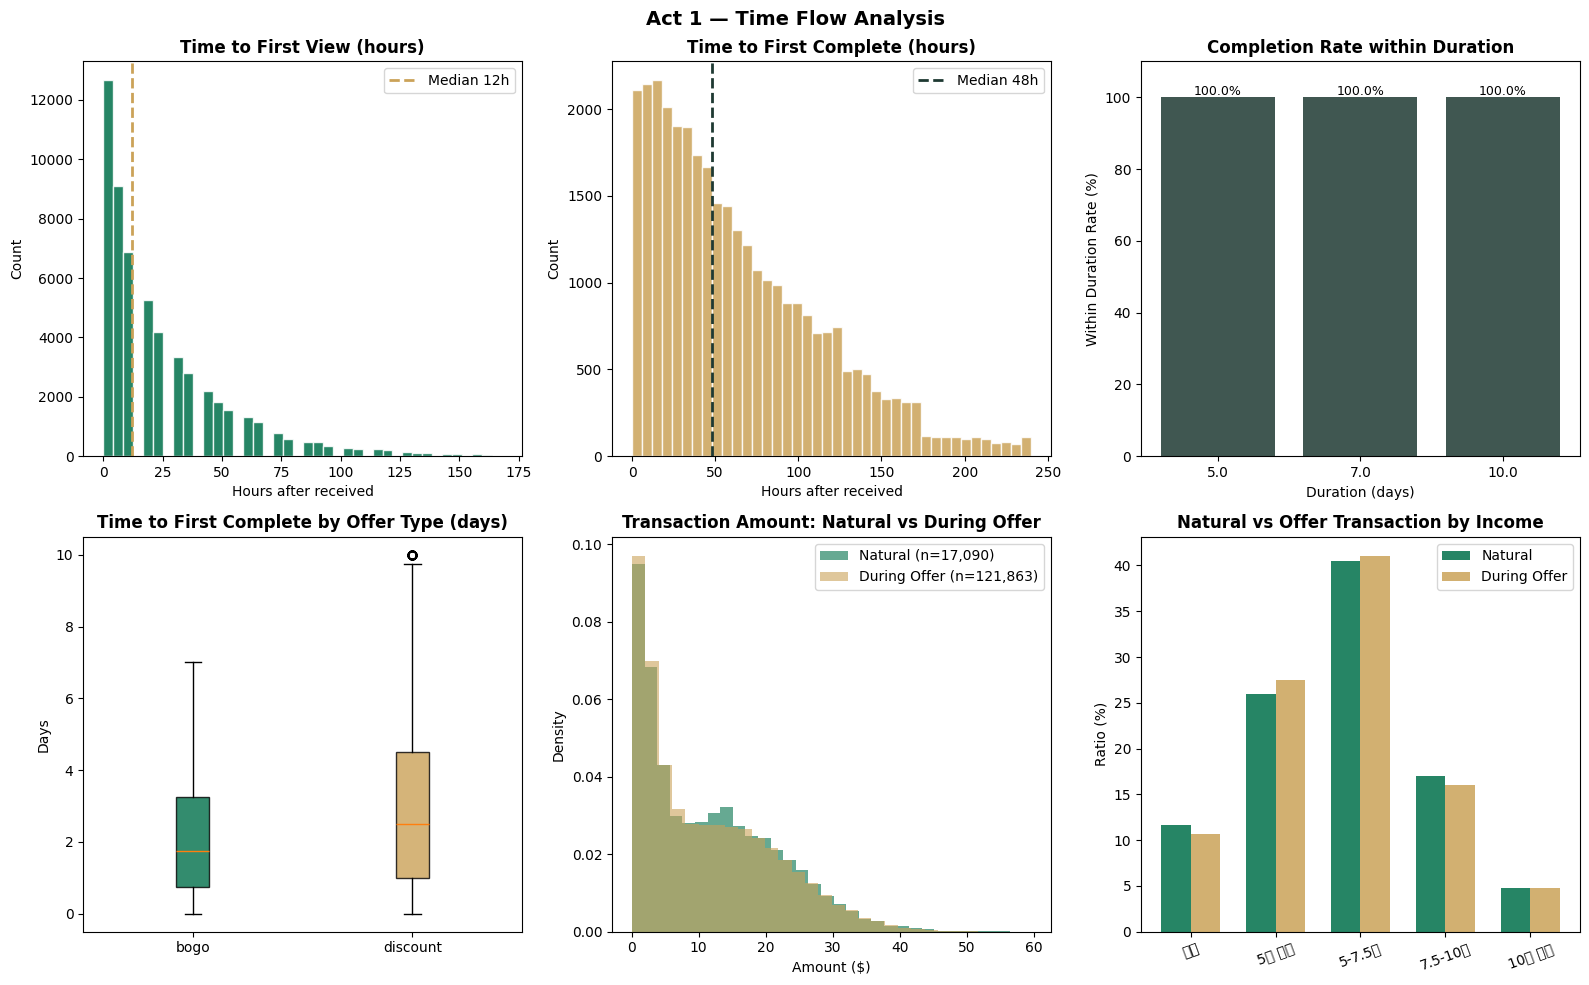

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Act 1 — Time Flow Analysis", fontsize=14, fontweight="bold")

# 스타벅스 컬러칩
green = "#00704A"
gold = "#CBA258"
dark = "#1E3932"
light = "#D4E9E2"
deep = "#006241"

# 차트 1: 수신 → 첫 열람 시간 분포
ax1 = axes[0, 0]
v_plot = funnel_instance["gap_to_view"].dropna()
v_plot = v_plot[v_plot <= 168]

ax1.hist(v_plot, bins=40, color=green, alpha=0.85, edgecolor="white")
ax1.axvline(v_plot.median(), color=gold, linestyle="--", linewidth=2, label=f"Median {v_plot.median():.0f}h")

ax1.set_title("Time to First View (hours)", fontweight="bold")
ax1.set_xlabel("Hours after received")
ax1.set_ylabel("Count")
ax1.legend()

# 차트 2: 수신 → 첫 완료 시간 분포
ax2 = axes[0, 1]
c_plot = funnel_instance["gap_to_complete"].dropna()
c_plot = c_plot[c_plot <= 240]

ax2.hist(c_plot, bins=40, color=gold, alpha=0.85, edgecolor="white")
ax2.axvline(c_plot.median(), color=dark, linestyle="--", linewidth=2, label=f"Median {c_plot.median():.0f}h")

ax2.set_title("Time to First Complete (hours)", fontweight="bold")
ax2.set_xlabel("Hours after received")
ax2.set_ylabel("Count")
ax2.legend()

# 차트 3: duration별 완료율
ax3 = axes[0, 2]
dur_data = completed_funnel_instance.groupby("offer_duration")["within_duration"].mean() * 100

ax3.bar(dur_data.index.astype(str), dur_data.values, color=dark, alpha=0.85)

for i, (d, v) in enumerate(dur_data.items()):
    ax3.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

ax3.set_title("Completion Rate within Duration", fontweight="bold")
ax3.set_xlabel("Duration (days)")
ax3.set_ylabel("Within Duration Rate (%)")
ax3.set_ylim(0, 110)

# 차트 4: 오퍼 유형별 반응 시간 박스플롯
ax4 = axes[1, 0]

box_data = [
    completed_funnel_instance.loc[completed_funnel_instance["offer_type_port"] == "bogo", "gap_to_complete"].dropna()
    / 24,
    completed_funnel_instance.loc[
        completed_funnel_instance["offer_type_port"] == "discount", "gap_to_complete"
    ].dropna()
    / 24,
]

bp = ax4.boxplot(box_data, labels=["bogo", "discount"], patch_artist=True)

for patch, color in zip(bp["boxes"], [green, gold]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax4.set_title("Time to First Complete by Offer Type (days)", fontweight="bold")
ax4.set_ylabel("Days")

# 차트 5: 자연 vs 오퍼 거래 금액
ax5 = axes[1, 1]

nat_plot = nact_tx.loc[nact_tx["amount"] <= 60, "amount"]
act_plot = act_tx.loc[act_tx["amount"] <= 60, "amount"]

ax5.hist(nat_plot, bins=30, alpha=0.6, color=green, label=f"Natural (n={len(nact_tx):,})", density=True)

ax5.hist(act_plot, bins=30, alpha=0.6, color=gold, label=f"During Offer (n={len(act_tx):,})", density=True)

ax5.set_title("Transaction Amount: Natural vs During Offer", fontweight="bold")
ax5.set_xlabel("Amount ($)")
ax5.set_ylabel("Density")
ax5.legend()

# 차트 6: 소득 구간 비교
ax6 = axes[1, 2]

inc_order = ["누락", "5만 미만", "5-7.5만", "7.5-10만", "10만 이상"]

nact_inc = nact_tx["income_group"].value_counts(normalize=True).reindex(inc_order, fill_value=0) * 100
act_inc = act_tx["income_group"].value_counts(normalize=True).reindex(inc_order, fill_value=0) * 100

x = range(len(inc_order))
w = 0.35

ax6.bar([i - w / 2 for i in x], nact_inc.values, w, label="Natural", color=green, alpha=0.85)
ax6.bar([i + w / 2 for i in x], act_inc.values, w, label="During Offer", color=gold, alpha=0.85)

ax6.set_xticks(list(x))
ax6.set_xticklabels(inc_order, rotation=20)
ax6.set_title("Natural vs Offer Transaction by Income", fontweight="bold")
ax6.set_ylabel("Ratio (%)")
ax6.legend()

plt.tight_layout()
plt.show()

# 보고서에 가정 명시
- 오퍼 인스턴스 단위로 is_aware 계산
- 유효기간(t_received ~ t_expire) 내 이벤트만 유효로 간주
- t_viewed <= t_completed 조건 만족 시 is_aware = 1
- ambiguous_match = 1인 케이스는 is_aware_reliable에서 제외

In [ ]:
# 확인
print("is_aware 분포:")
print(funnel_instance["is_aware"].value_counts())
print()
print("is_aware_reliable 분포 (ambiguous 제외):")
print(funnel_instance["is_aware_reliable"].value_counts())
print()


# 비교
total = len(funnel_instance)
old_aware = funnel_instance["valid_view_sequence"].sum()
new_aware = funnel_instance["is_aware"].sum()
reliable = funnel_instance["is_aware_reliable"].sum()

print(f"기존 valid_view_sequence : {old_aware:,}건 ({old_aware/total*100:.1f}%)")
print(f"개선 is_aware            : {new_aware:,}건 ({new_aware/total*100:.1f}%)")
print(f"신뢰 is_aware_reliable   : {reliable:,}건 ({reliable/total*100:.1f}%)")

is_aware 분포:
is_aware
0    53010
1    23267
Name: count, dtype: int64

is_aware_reliable 분포 (ambiguous 제외):
is_aware_reliable
0    54199
1    22078
Name: count, dtype: int64

기존 valid_view_sequence : 23,267건 (30.5%)
개선 is_aware            : 23,267건 (30.5%)
신뢰 is_aware_reliable   : 22,078건 (28.9%)
